#### Characterization of photoinduced isomerization and back-isomerization of the cyanine dye Cy5 by FCS (Widengren, Schwille)

In [1]:
import os
import sys

path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(
    splitted[0] + os.sep, splitted[1], splitted[2], splitted[3]
)
src_path = os.path.join(user_independent, "GitHub", "Photoswitching")
sys.path.append(src_path)

import src.blinking as bl
import src.distributions as dist
import src.emissions as em
import src.fcs as fcs_p
import src.figure as fi
import src.fluorophores as fl
import src.formulas as fo
import src.miscellaneous as mi
import src.network as net
import src.simulation as si
import src.prediction as pr
import src.analysis as an
import src.transitions as tr

import numpy as np
import pandas as pd

%load_ext autoreload
%autoreload 2

import warnings


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

c:\Users\vie43sq\Miniconda3\envs\MarkovModels\lib\site-packages\pycorrelate\pycorrelate.py:118: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def ucorrelate(t, u, maxlag=None):


#### 50 % Cis, 50% Trans under moderate excitation conditions

In [2]:
fluorophore = fl.Fluorophore(name='cy5', position=[0, 0])
fluorophore_system = fl.FluorophoreSystem([fluorophore])

irradiances = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50]
rng = np.random.default_rng(42)
cis_id = 6
trans_cis_ratios_widengren = []
trans_cis_ratios_gidi = []
for i, irradiance in enumerate(irradiances):
    transitions = fluorophore_system.load_transitions(
        irradiance=irradiance,
        wavelength=640,
        bleaching=False,
        energy_transfer=False,
        dstorm=False,
        )
    transition_set = tr.TransitionSet(transitions, fluorophore_system)
    transition_set = transition_set.adjust_rates({3:5e5})
    transition_set.finalize()
    cis_index = np.where(transition_set.single_states['cy5'] == cis_id)[0][0]

    prediction = pr.Prediction(transition_set)
    
    cis_occupation = prediction.state_occupations['cy5'][cis_index]
    trans_occupation = np.delete(prediction.state_occupations['cy5'], cis_index).sum()
    trans_cis_ratio = trans_occupation / cis_occupation
    trans_cis_ratios_widengren.append(trans_cis_ratio)


    transition_set = transition_set.adjust_rates({3:5e3})
    transition_set.finalize()
    cis_index = np.where(transition_set.single_states['cy5'] == cis_id)[0][0]

    prediction = pr.Prediction(transition_set)
    
    cis_occupation = prediction.state_occupations['cy5'][cis_index]
    trans_occupation = np.delete(prediction.state_occupations['cy5'], cis_index).sum()
    trans_cis_ratio = trans_occupation / cis_occupation
    trans_cis_ratios_gidi.append(trans_cis_ratio)

array([[<AxesSubplot:xlabel='irradiance [kW/cm²]', ylabel='occupation ratio'>]],
      dtype=object)

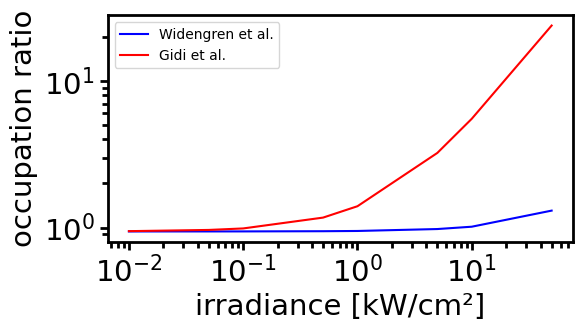

In [7]:
axes = fi.universal_figure(type_='line', data=[irradiances, trans_cis_ratios_widengren], xscale='log',
                    ylabel='occupation ratio', xlabel='irradiance [kW/cm²]',
                    label='Widengren et al.')
fi.universal_figure(type_='line', data=[irradiances, trans_cis_ratios_gidi], xscale='log',
                    ylabel='occupation ratio', xlabel='irradiance [kW/cm²]',
                    label='Gidi et al.', axes=axes, legend=True, color='red', yscale='log')

#### 'Turnover rate': excitation-emission cycles saturation when excitation rate comparable to deexcitation rate
Simulations say: not quite

In [2]:
fluorophore = fl.Fluorophore(name='cy5', position=[0, 0])
fluorophore_system = fl.FluorophoreSystem([fluorophore])
irradiances = [1, 5, 10, 50, 100, 500, 1000, 5000, 10000, 50000]
photons_collection = []
for irradiance in irradiances:
    transitions = fluorophore_system.load_transitions(
        irradiance=irradiance,
        wavelength=640,
        bleaching=False,
        energy_transfer=False,
        dstorm=False,
        )
    transition_set = tr.TransitionSet(transitions, fluorophore_system)
    transition_set = transition_set.adjust_rates({3:5e5})
    transition_set.finalize()

    prediction = pr.Prediction(transition_set)
    simulation = si.Simulation(transition_set)
    simulation.run(size=2e7, end_time=None, seed=42)
    emissions = em.Emissions()
    emissions.extract(simulation)
    photons_collection.append(emissions.event_time_series.mean())

In [18]:
_, _, frequencies = fo.convert_wavenumber_wavelength_frequency(wavelength=640)
photon_fluxes = fo.calculate_photon_flux(irradiances, frequencies)
excitation_rates = fo.calculate_excitation_rate(photon_fluxes, 2.5e5)
relative_rates = excitation_rates / (1/1e-9)

array([[<AxesSubplot:xlabel='x', ylabel='exc/deexc'>]], dtype=object)

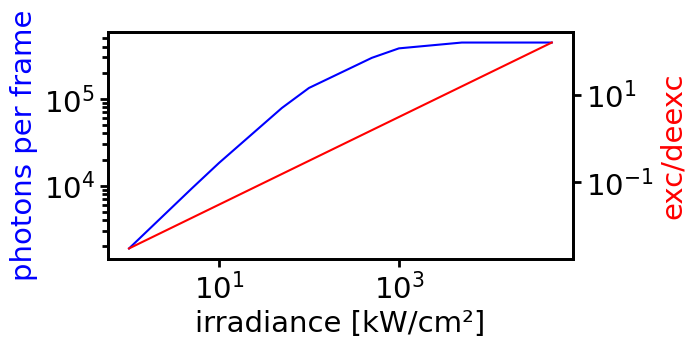

In [25]:
ax = fi.universal_figure(type_='line', data=[irradiances, photons_collection], xscale='log', xlabel='irradiance [kW/cm²]',
                    ylabel='photons per frame', ylabelcolor='blue', yscale='log')
ax2 = ax[0, 0].twinx()
fi.universal_figure(type_='line', data=[irradiances, relative_rates], xscale='log', axes=ax2, ylabel='exc/deexc', color='red',
                    ylabelcolor='red', yscale='log')

#### Fitting of FCS curve

In [43]:
irradiance = 2.5
fluorophore = fl.Fluorophore(name='cy5_widengren', position=[0, 0])
fluorophore_system = fl.FluorophoreSystem([fluorophore])

transitions = fluorophore_system.load_transitions(
    irradiance=irradiance,
    wavelength=640,
    bleaching=False,
    energy_transfer=False,
    dstorm=False,
    )
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()

prediction = pr.Prediction(transition_set)
simulation = si.Simulation(transition_set)
simulation.run(size=1e6, end_time=None, seed=42)
emissions = em.Emissions()
emissions.extract(simulation)
fcs = fcs_p.FCS(emissions).autocorrelate_time_points(exp_max=-4, exp_min=-11)

In [46]:
s0_index = np.where(transition_set.single_states['cy5_widengren'] == 0)[0][0]
s1_index = np.where(transition_set.single_states['cy5_widengren'] == 1)[0][0]
excitation_rate = transition_set.transition_df[transition_set.transition_df['abbreviation'] == 'EXC']['rate'].values[0]
k_isc = transition_set.transition_df[transition_set.transition_df['abbreviation'] == 'ISCST']['rate'].values[0]
k_T = transition_set.transition_df[transition_set.transition_df['abbreviation'] == 'ISCTS']['rate'].values[0]
k_iso = transition_set.transition_df[transition_set.transition_df['abbreviation'] == 'ISO']['rate'].values[0]
k_biso_eff = transition_set.transition_df[transition_set.transition_df['abbreviation'] == 'BISO']['rate'].values[0]
k_01 = 1 / prediction.mean_lifetimes['cy5_widengren'][s0_index]
k_10 = 1 / prediction.mean_lifetimes['cy5_widengren'][s1_index]

number_fluorophores = 1
antibunching = fcs_p.fit_antibunching(tau=fcs.tau, excitation_rate=excitation_rate,
                                      s1_lifetime=prediction.mean_lifetimes['cy5_widengren'][s1_index])
triplet_cis, norm = fcs_p.fit_triplet_cis(tau=fcs.tau, k_isc=k_isc, k_T=k_T, k_01=k_01, 
                                          k_10=k_10, k_iso=k_iso, k_biso_eff=k_biso_eff)
fit_combined = (antibunching + triplet_cis) / (norm * number_fluorophores) + 1

array([[<AxesSubplot:title={'center':'$\\tau_{min} = 1.39e-11$ s'}, xlabel='$\\tau \\ [s]$', ylabel='$G(\\tau)$'>]],
      dtype=object)

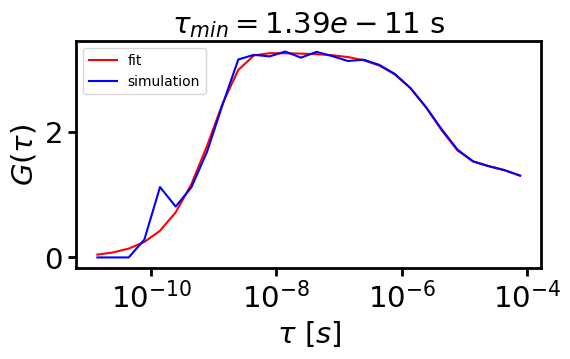

In [47]:
axes = fi.universal_figure(type_='line', data=[fcs.tau, fit_combined], label='fit', color='red')
fcs.plot(label='simulation', axes=axes, legend=True)

#### FCS curves with different irradiances

In [40]:
t1_index = np.where(transition_set.single_states['cy5'] == 3)[0][0]
fluorophore = fl.Fluorophore(name='cy5', position=[0, 0])
fluorophore_system = fl.FluorophoreSystem([fluorophore])
irradiances = [1, 10, 100]
fcs_results = []
for irradiance in irradiances:
    transitions = fluorophore_system.load_transitions(
        irradiance=irradiance,
        wavelength=640,
        bleaching=False,
        energy_transfer=False,
        dstorm=False,
        )
    transition_set = tr.TransitionSet(transitions, fluorophore_system)
    transition_set = transition_set.adjust_rates({3:5e5})
    transition_set.finalize()

    prediction = pr.Prediction(transition_set)
    print(f"T1 occupation: {prediction.state_occupations['cy5'][t1_index]}")
    simulation = si.Simulation(transition_set)
    simulation.run(size=1e6, end_time=None, seed=42)
    emissions = em.Emissions()
    emissions.extract(simulation)
    fcs = fcs_p.FCS(emissions).autocorrelate_time_points(exp_max=-4, exp_min=-11)
    fcs_results.append(fcs)

T1 occupation: 0.002332403607600123
T1 occupation: 0.02256501237277507
T1 occupation: 0.1702473031776859


WARNING for line:         ax.set_xscale(xscale)
 Data has no positive values, and therefore cannot be log-scaled. 


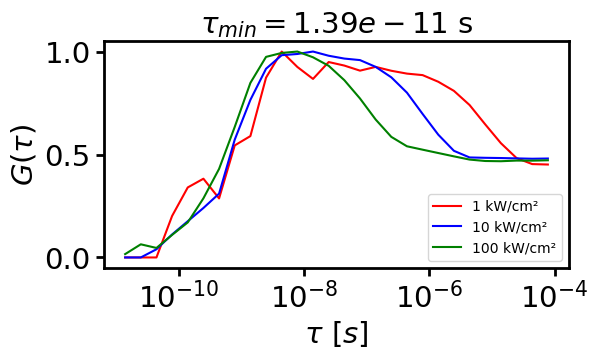

In [37]:
axes = fi.universal_figure()
colors = ['red', 'blue', 'green']
for i, fcs in enumerate(fcs_results):
    fcs.autocorrelation /= np.max(fcs.autocorrelation)
    axes = fcs.plot(label=f'{irradiances[i]} kW/cm²', axes=axes, legend=True, color=colors[i])

#### DNA shields Cy5 from collisional quenching by oxygen reducing ISC rates and reduces isomerization rates

In [47]:
t1_index = np.where(transition_set.single_states['cy5'] == 3)[0][0]
fluorophore = fl.Fluorophore(name='cy5', position=[0, 0])
fluorophore_system = fl.FluorophoreSystem([fluorophore])
irradiance = 40
isc_rates = [[8.3e5, 5e5], [4.3e5, 1.1e5]]
iso_rates = [[2e7, 2e6], [5e6, 1e6]]
fcs_results = []
for ((iscst, iscts), (iso, biso)) in zip(isc_rates, iso_rates):
    transitions = fluorophore_system.load_transitions(
        irradiance=irradiance,
        wavelength=640,
        bleaching=False,
        energy_transfer=False,
        dstorm=False,
        )
    transition_set = tr.TransitionSet(transitions, fluorophore_system)
    transition_set = transition_set.adjust_rates({2:iscst, 3:iscts, 4:iso, 5:biso})
    transition_set.finalize()

    prediction = pr.Prediction(transition_set)
    print(f"T1 occupation: {prediction.state_occupations['cy5'][t1_index]}")
    simulation = si.Simulation(transition_set)
    simulation.run(size=1e6, end_time=None, seed=42)
    emissions = em.Emissions()
    emissions.extract(simulation)
    fcs = fcs_p.FCS(emissions).autocorrelate_time_points(exp_max=-4, exp_min=-11)
    fcs_results.append(fcs)

T1 occupation: 0.0780903919083401
T1 occupation: 0.21274997628784637


WARNING for line:         ax.set_xscale(xscale)
 Data has no positive values, and therefore cannot be log-scaled. 


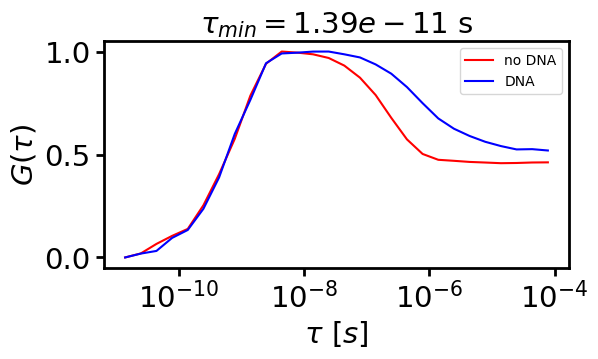

In [48]:
axes = fi.universal_figure()
colors = ['red', 'blue']
labels = ['no DNA', 'DNA']
for i, fcs in enumerate(fcs_results):
    fcs.autocorrelation /= np.max(fcs.autocorrelation)
    axes = fcs.plot(label=labels[i], axes=axes, legend=True, color=colors[i])

#### Figure 3

In [30]:
t1_index = np.where(transition_set.single_states['cy5'] == 3)[0][0]
fluorophore = fl.Fluorophore(name='cy5', position=[0, 0])
fluorophore_system = fl.FluorophoreSystem([fluorophore])
irradiances = [0.1, 0.5, 1, 5, 10, 50, 100, 500, 1000]
z_2s = []
z_3s = []
for irradiance in irradiances:
    transitions = fluorophore_system.load_transitions(
        irradiance=irradiance,
        wavelength=640,
        bleaching=False,
        energy_transfer=False,
        dstorm=False,
        )
    transition_set = tr.TransitionSet(transitions, fluorophore_system)
    transition_set = transition_set.adjust_rates({3:5e5})
    transition_set.finalize()

    prediction = pr.Prediction(transition_set)
    # print(f"T1 occupation: {prediction.state_occupations['cy5'][t1_index]}")
    # simulation = si.Simulation(transition_set)
    # simulation.run(size=1e6, end_time=None, seed=42)
    # emissions = em.Emissions()
    # emissions.extract(simulation)
    # fcs = fcs_p.FCS(emissions).autocorrelate_time_points(exp_max=-4, exp_min=-11)
    # fcs_results.append(fcs)
    s0_index = np.where(transition_set.single_states['cy5'] == 0)[0][0]
    s1_index = np.where(transition_set.single_states['cy5'] == 1)[0][0]
    excitation_rate = transition_set.transition_df[transition_set.transition_df['abbreviation'] == 'EXC']['rate'].values[0]
    k_isc = transition_set.transition_df[transition_set.transition_df['abbreviation'] == 'ISCST']['rate'].values[0]
    k_T = transition_set.transition_df[transition_set.transition_df['abbreviation'] == 'ISCTS']['rate'].values[0]
    k_iso = transition_set.transition_df[transition_set.transition_df['abbreviation'] == 'ISO']['rate'].values[0]
    k_biso_eff = transition_set.transition_df[transition_set.transition_df['abbreviation'] == 'BISO']['rate'].values[0]
    k_01 = 1 / prediction.mean_lifetimes['cy5'][s0_index]
    k_10 = 1 / prediction.mean_lifetimes['cy5'][s1_index]
    

    k_isc_eff = k_01 / (k_01 + k_10) * k_isc
    k_iso_eff = k_01 / (k_01 + k_10) * k_iso

    eigen_1 = 0

    part_1 = (k_isc_eff + k_T + k_iso_eff + k_biso_eff) / 2
    part_2 = (
        (k_isc_eff + k_T + k_iso_eff + k_biso_eff) ** 2 / 4
        - k_iso_eff * k_T
        - k_isc_eff * k_biso_eff
        - k_T * k_biso_eff
    ) ** 0.5
    eigen_2 = -(part_1 + part_2)
    eigen_3 = -(part_1 - part_2)

    alpha = k_iso_eff * k_T + k_isc_eff * k_biso_eff + k_T * k_biso_eff
    beta = k_isc_eff + k_iso_eff + k_T - k_biso_eff
    gamma = (
        (k_isc_eff + k_iso_eff) ** 2
        + (k_biso_eff - k_T) ** 2
        + 2 * (k_iso_eff - k_isc_eff) * (k_biso_eff - k_T)
    ) ** 0.5
    delta = (
        k_T * (k_iso_eff + k_biso_eff - k_T - k_isc_eff) + 2 * k_isc_eff * k_biso_eff
    )

    z_1 = k_T * k_biso_eff / alpha
    z_2 = (beta + gamma) * (k_T * gamma + delta) / (4 * alpha * gamma)
    z_3 = (beta - gamma) * (k_T * gamma - delta) / (4 * alpha * gamma)

    z_2s.append(z_2)
    z_3s.append(z_3)


array([[<AxesSubplot:xlabel='irradiance [kW/cm²]', ylabel='relative amplitudes'>]],
      dtype=object)

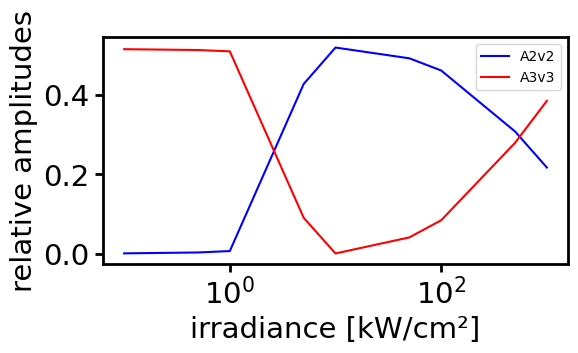

In [34]:
ax = fi.universal_figure(type_='line', data=[irradiances, z_2s], xscale='log', xlabel='irradiance [kW/cm²]', label='A2v2')
fi.universal_figure(type_='line', data=[irradiances, z_3s], xscale='log', xlabel='irradiance [kW/cm²]', axes=ax, color='red',
                    label='A3v3', legend=True, ylabel='relative amplitudes')